In [115]:
# 1. Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
# 2. Load the Dataset

df = pd.read_csv("../datasets/raw/telco_churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [117]:
# 3. Clean TotalCharges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Missing values:", df["TotalCharges"].isnull().sum())

TotalCharges dtype: float64
Missing values: 0


In [118]:
# 4. Remove Identifier Column from Modeling Data

customer_ids = df["customerID"].copy() #save customer_ids because later, for a high-risk customer table, IDs can be useful

df = df.drop(columns=["customerID"])

print("Dataset Shape After Removing customerID:", df.shape)

Dataset Shape After Removing customerID: (7043, 20)


In [119]:
# 5. Separate Features and Target Variable

X = df.drop(columns=["Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Feature Shape: (7043, 19)
Target Shape: (7043,)

Target Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [120]:
# 6. Split Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #stratify=y keeps approximately the same churn proportion in both train and test sets.
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (5634, 19)
Testing Set Shape: (1409, 19)


In [121]:
# 7. Define Numerical and Categorical Features

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X.columns
    if col not in numerical_features
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [122]:
# 8. Create Numerical Preprocessing Pipeline

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [123]:
# 9. Create Categorical Preprocessing Pipeline

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [124]:
# 10. Combine Numerical and Categorical Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [125]:
# 11. Create Logistic Regression Model Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully.") 

Logistic Regression pipeline created successfully.


In [126]:
# 12. Train Logistic Regression Model

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [127]:
# 13. Generate Predictions on Test Data

y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [128]:
# 14. Evaluate Logistic Regression Model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.8055
Precision : 0.6572
Recall    : 0.5588
F1 Score  : 0.6040
ROC-AUC   : 0.8420


In [129]:
# 15. Display Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Confusion Matrix:
[[926 109]
 [165 209]]


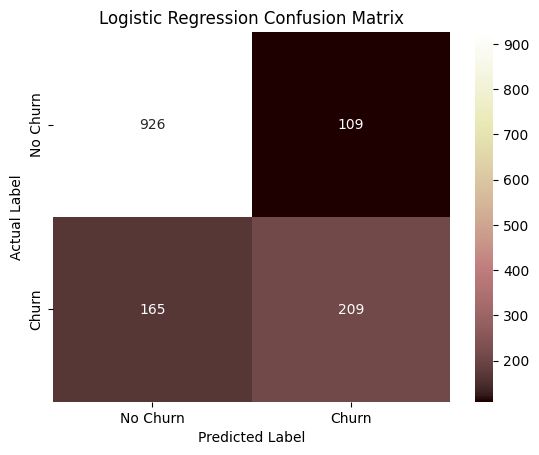

In [130]:
# 17. Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="pink",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [131]:
# 19. Compare Classification Thresholds

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.519337,0.754011,0.615049
1,0.35,0.543210,0.705882,0.613953
2,0.40,0.568182,0.668449,0.614251
3,0.45,0.600522,0.614973,0.607662
4,0.50,0.657233,0.558824,0.604046


In [132]:
# 20. Create Random Forest Model Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [133]:
# 21. Train Random Forest Model

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

# 22. Generate Random Forest Predictions

rf_y_pred = random_forest_pipeline.predict(X_test)

rf_y_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest model trained successfully.
Random Forest predictions generated successfully.


In [134]:
# 23. Evaluate Random Forest Model

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_prob)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

Accuracy  : 0.7828
Precision : 0.6164
Recall    : 0.4813
F1 Score  : 0.5405
ROC-AUC   : 0.8196


In [135]:
# 24. Display Random Forest Classification Report

print(
    classification_report(
        y_test,
        rf_y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [136]:
# 25. Create XGBoost Model Pipeline

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [137]:
# 25. Create XGBoost Model Pipeline

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [138]:
# 26. Train XGBoost Model

xgb_pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [139]:
# 27. Generate XGBoost Predictions

xgb_y_pred = xgb_pipeline.predict(X_test)

xgb_y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated successfully.")

XGBoost predictions generated successfully.


In [140]:
# 28. Evaluate XGBoost Model

xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_prob)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}")

Accuracy  : 0.8006
Precision : 0.6535
Recall    : 0.5294
F1 Score  : 0.5849
ROC-AUC   : 0.8439


In [141]:
# 29. Display XGBoost Classification Report

print(
    classification_report(
        y_test,
        xgb_y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [142]:
# 30. Compare Models Using Stratified Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgb_pipeline
}

cv_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8019,0.6521,0.5438,0.5924,0.8461
1,Random Forest,0.7865,0.6282,0.4816,0.5448,0.8196
2,XGBoost,0.8044,0.6660,0.5291,0.5894,0.8470


In [143]:
# 31. Generate Out-of-Fold Probabilities for Threshold Selection

from sklearn.model_selection import cross_val_predict

oof_prob = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF probabilities generated:", len(oof_prob))

OOF probabilities generated: 5634


In [144]:
# 32. Evaluate Candidate Thresholds Using OOF Predictions

thresholds = np.arange(0.25, 0.56, 0.05)

oof_threshold_results = []

for candidate_threshold in thresholds:

    oof_pred = (oof_prob >= candidate_threshold).astype(int)

    oof_threshold_results.append({
        "Threshold": round(candidate_threshold, 2),
        "Precision": precision_score(y_train, oof_pred),
        "Recall": recall_score(y_train, oof_pred),
        "F1 Score": f1_score(y_train, oof_pred)
    })

oof_threshold_df = pd.DataFrame(oof_threshold_results)

oof_threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.25,0.5088,0.8167,0.6270
1,0.30,0.5411,0.7666,0.6344
2,0.35,0.5705,0.7171,0.6354
3,0.40,0.5937,0.6635,0.6267
4,0.45,0.6239,0.6013,0.6124
5,0.50,0.6520,0.5438,0.5930
6,0.55,0.6852,0.4863,0.5689


In [145]:
# 33. Select Best Threshold Based on OOF F1 Score

best_row = oof_threshold_df.loc[
    oof_threshold_df["F1 Score"].idxmax()
]

selected_threshold = float(
    best_row["Threshold"]
)

print("Selected threshold:", selected_threshold)
print("OOF F1 score:", best_row["F1 Score"])
print("OOF recall:", best_row["Recall"])
print("OOF precision:", best_row["Precision"])

Selected threshold: 0.35
OOF F1 score: 0.6354475400118553
OOF recall: 0.717056856187291
OOF precision: 0.5705162320383182


In [146]:
# 33. Evaluate Final Logistic Regression Model at Selected Threshold

final_y_pred = (y_prob >= selected_threshold).astype(int)

final_accuracy = accuracy_score(y_test, final_y_pred)
final_precision = precision_score(y_test, final_y_pred)
final_recall = recall_score(y_test, final_y_pred)
final_f1 = f1_score(y_test, final_y_pred)
final_roc_auc = roc_auc_score(y_test, y_prob)

print(f"Selected Threshold : {selected_threshold}")
print(f"Accuracy           : {final_accuracy:.4f}")
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")
print(f"F1 Score           : {final_f1:.4f}")
print(f"ROC-AUC            : {final_roc_auc:.4f}")

Selected Threshold : 0.35
Accuracy           : 0.7644
Precision          : 0.5432
Recall             : 0.7059
F1 Score           : 0.6140
ROC-AUC            : 0.8420


In [147]:
# 34. Generate Final Confusion Matrix

final_cm = confusion_matrix(y_test, final_y_pred)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[813 222]
 [110 264]]


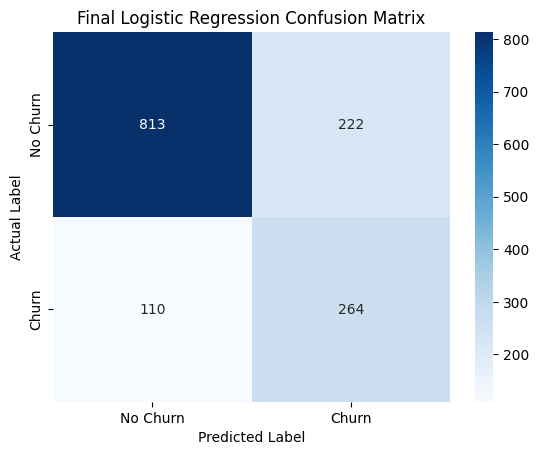

In [148]:
# 35. Visualize Final Confusion Matrix

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Final Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [149]:
# 36. Save Final Model Pipeline and Selected Threshold

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    logistic_pipeline,
    "../models/churn_pipeline.pkl"
)

joblib.dump(
    selected_threshold,
    "../models/churn_threshold.pkl"
)

print("Final pipeline and threshold saved successfully.")   

Final pipeline and threshold saved successfully.


In [150]:
# 37. Load and Verify Saved Model

loaded_pipeline = joblib.load("../models/churn_pipeline.pkl")
loaded_threshold = joblib.load("../models/churn_threshold.pkl")

loaded_prob = loaded_pipeline.predict_proba(X_test)[:, 1]
loaded_pred = (loaded_prob >= loaded_threshold).astype(int)

print(
    "Probabilities match:",
    np.allclose(y_prob, loaded_prob)
)

print(
    "Predictions match:",
    np.array_equal(final_y_pred, loaded_pred)
)

print("Loaded threshold:", loaded_threshold)

Probabilities match: True
Predictions match: True
Loaded threshold: 0.35


In [151]:
# 38. Identify TP, TN, FP and FN Test Examples

comparison_df = X_test.copy()

comparison_df["Actual"] = y_test.values
comparison_df["Predicted"] = final_y_pred
comparison_df["Churn_Probability"] = y_prob

tp_example = comparison_df[
    (comparison_df["Actual"] == 1) &
    (comparison_df["Predicted"] == 1)
].iloc[0]

tn_example = comparison_df[
    (comparison_df["Actual"] == 0) &
    (comparison_df["Predicted"] == 0)
].iloc[0]

fp_example = comparison_df[
    (comparison_df["Actual"] == 0) &
    (comparison_df["Predicted"] == 1)
].iloc[0]

fn_example = comparison_df[
    (comparison_df["Actual"] == 1) &
    (comparison_df["Predicted"] == 0)
].iloc[0]

print("TP found:", tp_example["Actual"], tp_example["Predicted"])
print("TN found:", tn_example["Actual"], tn_example["Predicted"])
print("FP found:", fp_example["Actual"], fp_example["Predicted"])
print("FN found:", fn_example["Actual"], fn_example["Predicted"])

TP found: 1 1
TN found: 0 0
FP found: 0 1
FN found: 1 0


In [152]:
# 39. Verify Flask API Predictions Against Notebook Predictions

import requests

API_URL = "http://127.0.0.1:5000/predict"

test_examples = {
    "True Positive": tp_example,
    "True Negative": tn_example,
    "False Positive": fp_example,
    "False Negative": fn_example
}

for example_name, example in test_examples.items():

    # Keep only original model input features
    customer_input = example[X_test.columns].to_dict()

    # Convert NumPy values into JSON-compatible Python values
    customer_input = {
        key: value.item() if hasattr(value, "item") else value
        for key, value in customer_input.items()
    }

    response = requests.post(
        API_URL,
        json=customer_input,
        timeout=10
    )

    result = response.json()

    print(f"\n--- {example_name} ---")
    print("Actual Label        :", int(example["Actual"]))
    print("Notebook Prediction :", int(example["Predicted"]))
    print(
        "Notebook Probability:",
        round(float(example["Churn_Probability"]), 4)
    )
    print("API Prediction      :", result["prediction"])
    print("API Probability     :", result["churn_probability"])


--- True Positive ---
Actual Label        : 1
Notebook Prediction : 1
Notebook Probability: 0.3955
API Prediction      : Churn
API Probability     : 0.3955

--- True Negative ---
Actual Label        : 0
Notebook Prediction : 0
Notebook Probability: 0.0461
API Prediction      : No Churn
API Probability     : 0.0461

--- False Positive ---
Actual Label        : 0
Notebook Prediction : 1
Notebook Probability: 0.6836
API Prediction      : Churn
API Probability     : 0.6836

--- False Negative ---
Actual Label        : 1
Notebook Prediction : 0
Notebook Probability: 0.184
API Prediction      : No Churn
API Probability     : 0.184


In [153]:
# 40. Inspect Final Pipeline Before SHAP Integration

print(logistic_pipeline)

print("\nPipeline Steps:")
print(logistic_pipeline.named_steps)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown=

In [154]:
# 41. Extract Preprocessor and Classifier for SHAP

preprocessor = logistic_pipeline.named_steps["preprocessor"]
classifier = logistic_pipeline.named_steps["classifier"]

print("Preprocessor:")
print(type(preprocessor))

print("\nClassifier:")
print(type(classifier))

Preprocessor:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

Classifier:
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [155]:
# 42. Transform Data and Extract Feature Names

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Original number of features:", X_train.shape[1])
print("Transformed number of features:", X_train_transformed.shape[1])
print("Number of feature names:", len(feature_names))

print("\nFirst 10 transformed feature names:")
print(feature_names[:10])

Original number of features: 19
Transformed number of features: 46
Number of feature names: 46

First 10 transformed feature names:
['num__tenure' 'num__MonthlyCharges' 'num__TotalCharges'
 'cat__gender_Female' 'cat__gender_Male' 'cat__SeniorCitizen_0'
 'cat__SeniorCitizen_1' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No']


In [156]:
# 43. Create SHAP Explainer

import shap

explainer = shap.LinearExplainer(
    classifier,
    X_train_transformed
)

shap_values = explainer(X_test_transformed)

print("SHAP values shape:", shap_values.values.shape)
print("Test data shape:", X_test_transformed.shape)

SHAP values shape: (1409, 46)
Test data shape: (1409, 46)


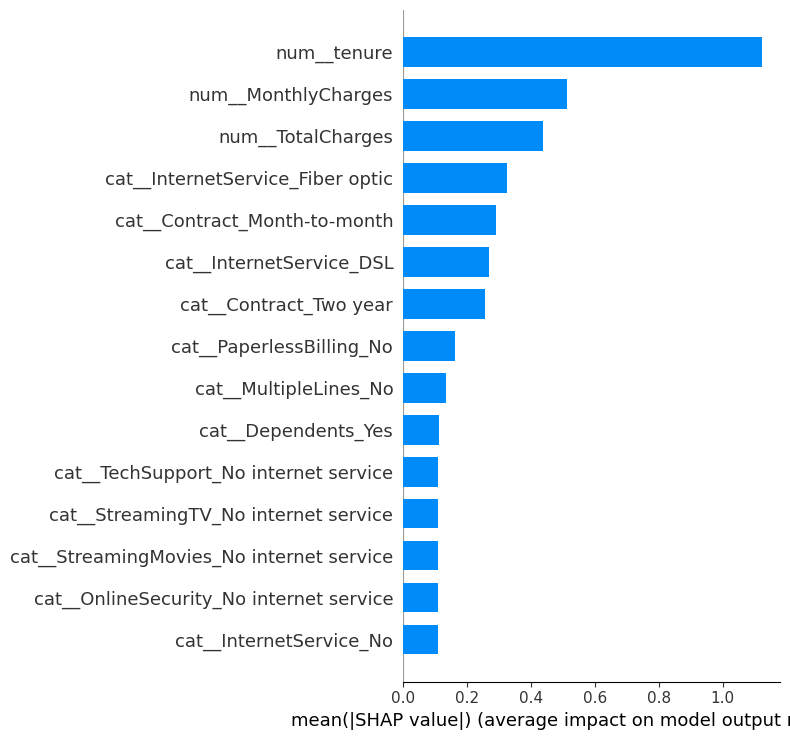

In [157]:
# 44. Global SHAP Feature Importance

shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)

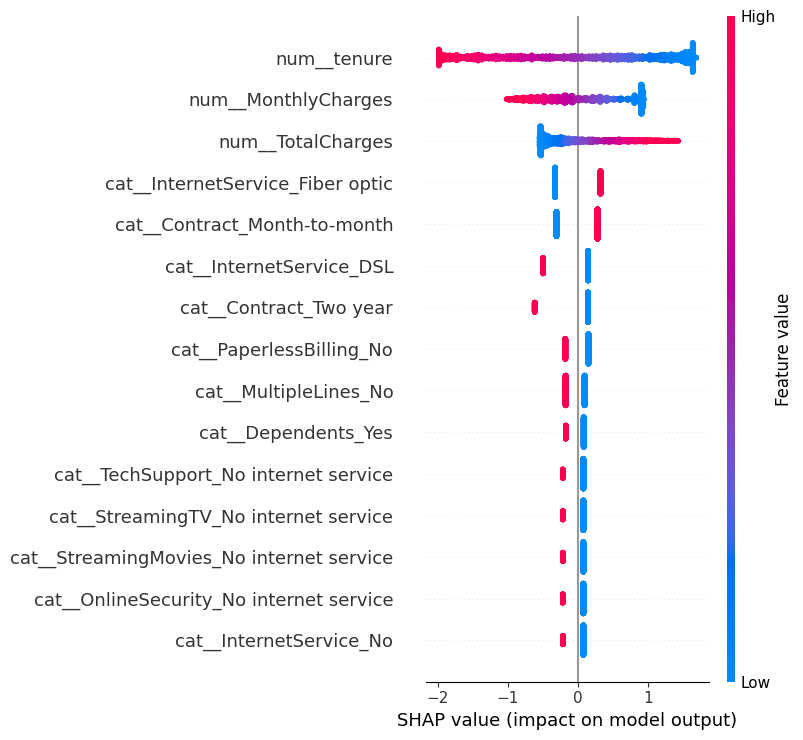

In [158]:
# 45. SHAP Beeswarm Plot

shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

Actual Label: 0
Predicted Probability: 0.046058570090220685


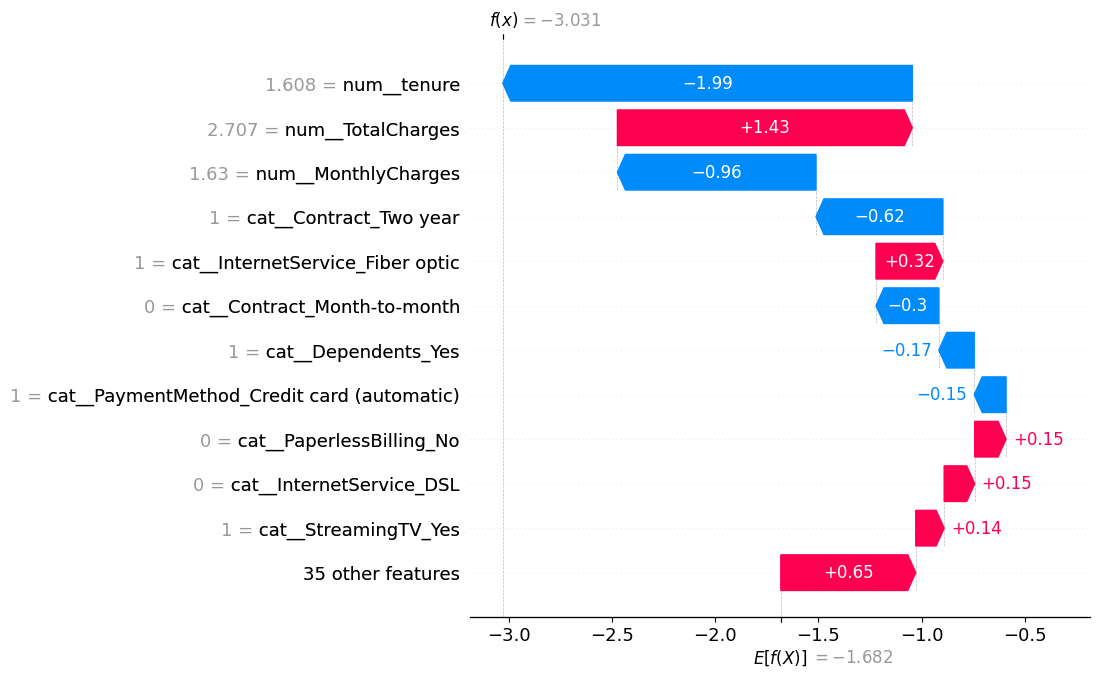

In [159]:
# 46. Local SHAP Explanation for One Customer

customer_index = 0

print("Actual Label:", y_test.iloc[customer_index])

print(
    "Predicted Probability:",
    logistic_pipeline.predict_proba(
        X_test.iloc[[customer_index]]
    )[0][1]
)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values.values[customer_index],
        base_values=shap_values.base_values[customer_index],
        data=X_test_transformed[customer_index],
        feature_names=feature_names
    ),
    max_display=12
)

In [160]:
# 47. Extract Top SHAP Factors for One Customer

customer_index = 0

customer_shap = shap_values.values[customer_index]

explanation_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": customer_shap
})

# Factors pushing prediction toward Churn
churn_factors = (
    explanation_df[explanation_df["SHAP Value"] > 0]
    .sort_values("SHAP Value", ascending=False)
    .head(3)
)

# Factors pushing prediction toward Retention
retention_factors = (
    explanation_df[explanation_df["SHAP Value"] < 0]
    .sort_values("SHAP Value", ascending=True)
    .head(3)
)

print("Factors pushing toward CHURN:")
print(churn_factors)

print("\nFactors pushing toward RETENTION:")
print(retention_factors)

Factors pushing toward CHURN:
                             Feature  SHAP Value
2                  num__TotalCharges    1.430165
17  cat__InternetService_Fiber optic    0.324014
40          cat__PaperlessBilling_No    0.152138

Factors pushing toward RETENTION:
                   Feature  SHAP Value
0              num__tenure   -1.986021
1      num__MonthlyCharges   -0.962932
39  cat__Contract_Two year   -0.615115


In [161]:
# 48. Convert SHAP Factors into Human-Readable Explanations

def make_readable_factor(feature_name, raw_customer):

    # Remove pipeline prefixes
    clean_name = feature_name.replace("num__", "").replace("cat__", "")

    # Numeric features
    if clean_name == "tenure":
        tenure_value = raw_customer["tenure"]

        if tenure_value <= 12:
            return "Short customer tenure"
        elif tenure_value >= 48:
            return "Long customer tenure"
        else:
            return "Customer tenure"


    elif clean_name == "MonthlyCharges":
        monthly_value = raw_customer["MonthlyCharges"]

        if monthly_value >= 70:
            return "High monthly charges"
        elif monthly_value <= 35:
            return "Low monthly charges"
        else:
            return "Moderate monthly charges"


    elif clean_name == "TotalCharges":
        return "Total billing history"


    # Categorical features
    if "_" in clean_name:
        column, category = clean_name.split("_", 1)

        readable_columns = {
            "Contract": "Contract",
            "InternetService": "Internet service",
            "PaymentMethod": "Payment method",
            "TechSupport": "Tech support",
            "OnlineSecurity": "Online security",
            "OnlineBackup": "Online backup",
            "DeviceProtection": "Device protection",
            "PaperlessBilling": "Paperless billing",
            "Dependents": "Dependents",
            "Partner": "Partner",
            "MultipleLines": "Multiple lines",
            "StreamingTV": "Streaming TV",
            "StreamingMovies": "Streaming movies",
            "PhoneService": "Phone service",
            "gender": "Gender",
            "SeniorCitizen": "Senior citizen"
        }

        readable_column = readable_columns.get(column, column)

        return f"{readable_column}: {category}"

    return clean_name

In [162]:
# Select raw customer data

raw_customer = X_test.iloc[customer_index]


print("Factors pushing toward CHURN:")

for feature in churn_factors["Feature"]:
    print("•", make_readable_factor(feature, raw_customer))


print("\nFactors pushing toward RETENTION:")

for feature in retention_factors["Feature"]:
    print("•", make_readable_factor(feature, raw_customer))

Factors pushing toward CHURN:
• Total billing history
• Internet service: Fiber optic
• Paperless billing: No

Factors pushing toward RETENTION:
• Long customer tenure
• High monthly charges
• Contract: Two year


In [163]:
# 49. Check Whether a Categorical SHAP Feature Is Active

def is_active_feature(feature_name, raw_customer):

    # Numeric features are always valid
    if feature_name.startswith("num__"):
        return True

    clean_name = feature_name.replace("cat__", "")

    # Find matching original column and category
    for column in raw_customer.index:

        prefix = column + "_"

        if clean_name.startswith(prefix):

            category = clean_name[len(prefix):]

            return str(raw_customer[column]) == category

    return False

In [164]:
# Filter only valid active features

valid_churn_factors = churn_factors[
    churn_factors["Feature"].apply(
        lambda feature: is_active_feature(feature, raw_customer)
    )
]

valid_retention_factors = retention_factors[
    retention_factors["Feature"].apply(
        lambda feature: is_active_feature(feature, raw_customer)
    )
]


print("Factors pushing toward CHURN:")

for feature in valid_churn_factors["Feature"]:
    print("•", make_readable_factor(feature, raw_customer))


print("\nFactors pushing toward RETENTION:")

for feature in valid_retention_factors["Feature"]:
    print("•", make_readable_factor(feature, raw_customer))

Factors pushing toward CHURN:
• Total billing history
• Internet service: Fiber optic

Factors pushing toward RETENTION:
• Long customer tenure
• High monthly charges
• Contract: Two year


In [165]:
# 50. Create Reusable Customer Explanation Function

def get_customer_explanation(
    customer_index,
    shap_values,
    feature_names,
    X_raw,
    top_n=3
):

    # Raw customer data
    raw_customer = X_raw.iloc[customer_index]

    # SHAP values for this customer
    customer_shap = shap_values.values[customer_index]

    # Create explanation table
    explanation_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP Value": customer_shap
    })

    # Keep numeric features and active categorical features only
    explanation_df = explanation_df[
        explanation_df["Feature"].apply(
            lambda feature: is_active_feature(
                feature,
                raw_customer
            )
        )
    ]

    # Top factors pushing toward churn
    churn_factors = (
        explanation_df[
            explanation_df["SHAP Value"] > 0
        ]
        .sort_values(
            "SHAP Value",
            ascending=False
        )
        .head(top_n)
    )

    # Top factors pushing toward retention
    retention_factors = (
        explanation_df[
            explanation_df["SHAP Value"] < 0
        ]
        .sort_values(
            "SHAP Value",
            ascending=True
        )
        .head(top_n)
    )

    # Convert technical names into readable text
    churn_explanations = [
        make_readable_factor(feature, raw_customer)
        for feature in churn_factors["Feature"]
    ]

    retention_explanations = [
        make_readable_factor(feature, raw_customer)
        for feature in retention_factors["Feature"]
    ]

    return churn_explanations, retention_explanations

In [166]:
# 51. Test Reusable Customer Explanation Function

churn_reasons, retention_reasons = get_customer_explanation(
    customer_index=0,
    shap_values=shap_values,
    feature_names=feature_names,
    X_raw=X_test,
    top_n=3
)

print("Factors pushing toward CHURN:")

for reason in churn_reasons:
    print("•", reason)


print("\nFactors pushing toward RETENTION:")

for reason in retention_reasons:
    print("•", reason)

Factors pushing toward CHURN:
• Total billing history
• Internet service: Fiber optic
• Streaming TV: Yes

Factors pushing toward RETENTION:
• Long customer tenure
• High monthly charges
• Contract: Two year


In [167]:
# 52. Save SHAP Explainer and Feature Names

import joblib

joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

joblib.dump(
    feature_names,
    "../models/shap_feature_names.pkl"
)

print("SHAP explainer and feature names saved successfully.")

SHAP explainer and feature names saved successfully.


In [168]:
# 53. Verify Saved SHAP Explainer

loaded_explainer = joblib.load(
    "../models/shap_explainer.pkl"
)

loaded_feature_names = joblib.load(
    "../models/shap_feature_names.pkl"
)

loaded_shap_values = loaded_explainer(
    X_test_transformed[:1]
)

print(
    "SHAP values match:",
    np.allclose(
        shap_values.values[0],
        loaded_shap_values.values[0]
    )
)

print(
    "Feature names match:",
    np.array_equal(
        feature_names,
        loaded_feature_names
    )
)

SHAP values match: True
Feature names match: True


In [169]:
print("Threshold used in evaluation:", threshold)

saved_threshold = joblib.load("../models/churn_threshold.pkl")

print("Notebook threshold:", threshold)
print("Saved app threshold:", saved_threshold)

Threshold used in evaluation: 0.5
Notebook threshold: 0.5
Saved app threshold: 0.35


In [170]:
# 55. Evaluate Final Model Using Deployed Threshold

import joblib

deployed_threshold = joblib.load(
    "../models/churn_threshold.pkl"
)

print("Deployed threshold:", deployed_threshold)

# Probabilities are already available,
# but calculate again for clarity
y_test_probability = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

# Apply actual deployed threshold
y_pred_deployed = (
    y_test_probability >= deployed_threshold
).astype(int)


print("\nFINAL DEPLOYED MODEL EVALUATION")
print("--------------------------------")

print(
    f"Accuracy  : {accuracy_score(y_test, y_pred_deployed):.4f}"
)

print(
    f"Precision : {precision_score(y_test, y_pred_deployed):.4f}"
)

print(
    f"Recall    : {recall_score(y_test, y_pred_deployed):.4f}"
)

print(
    f"F1 Score  : {f1_score(y_test, y_pred_deployed):.4f}"
)

print(
    f"ROC-AUC   : {roc_auc_score(y_test, y_test_probability):.4f}"
)


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_deployed
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_deployed,
        target_names=["No Churn", "Churn"]
    )
)

Deployed threshold: 0.35

FINAL DEPLOYED MODEL EVALUATION
--------------------------------
Accuracy  : 0.7644
Precision : 0.5432
Recall    : 0.7059
F1 Score  : 0.6140
ROC-AUC   : 0.8420

Confusion Matrix:
[[813 222]
 [110 264]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [171]:
# 56. Create Final Model Evaluation Summary

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Selected Threshold"
    ],

    "Value": [
        accuracy_score(y_test, final_y_pred),
        precision_score(y_test, final_y_pred),
        recall_score(y_test, final_y_pred),
        f1_score(y_test, final_y_pred),
        roc_auc_score(y_test, y_prob),
        selected_threshold
    ]
})

final_metrics["Value"] = final_metrics["Value"].round(4)

final_metrics

,Metric,Value
0,Accuracy,0.7644
1,Precision,0.5432
2,Recall,0.7059
3,F1 Score,0.6140
4,ROC-AUC,0.8420
5,Selected Threshold,0.3500


In [172]:
# 57. Save Final Model Metrics Report

final_metrics.to_csv(
    "../reports/final_model_metrics.csv",
    index=False
)

print("Final model metrics saved successfully.")

Final model metrics saved successfully.


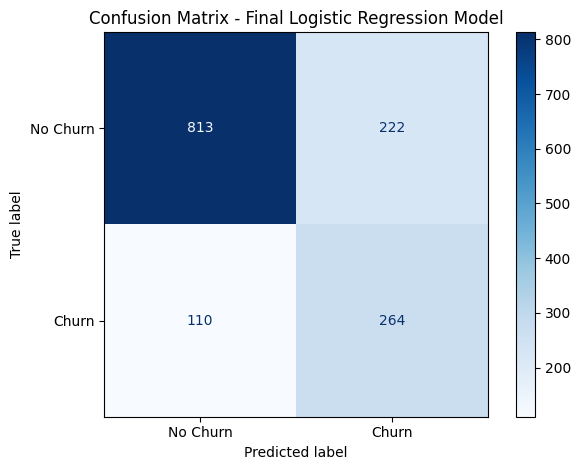

Final confusion matrix saved successfully.


In [173]:
# 58. Save Final Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Final Logistic Regression Model"
)

plt.tight_layout()

plt.savefig(
    "../reports/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final confusion matrix saved successfully.")

In [174]:
# 59. Save Cross-Validation Model Comparison Report

cv_results_df.round(4).to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Model comparison report saved successfully.")

Model comparison report saved successfully.


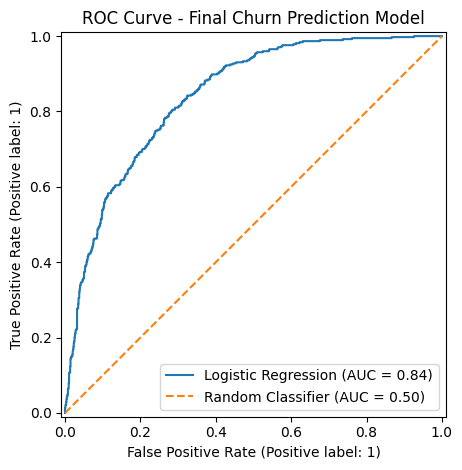

ROC curve saved successfully.


In [176]:
# 60. Save ROC Curve for Final Model

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

# Add random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.50)"
)

plt.title("ROC Curve - Final Churn Prediction Model")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/final_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")